In [21]:
from langgraph.graph import MessagesState
from langchain_openai import ChatOpenAI
from dotenv import load_dotenv
from langchain_core.messages import HumanMessage, RemoveMessage
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import InMemorySaver

In [22]:
load_dotenv()

True

In [23]:
model = ChatOpenAI()

In [24]:
class ChatState(MessagesState):
    summary : str

# Creating Node functionality

In [25]:
def chat_node(state : ChatState):
    # two possible cases here.
    # If there is summary -> then provide it in context
    # if there is no summary then there is no need to provide it in context
    summary = state['summary']
    messages = []

    if summary:
        messages.append({
            "role": "system",
            "content": f"Conversation summary:\n{state['summary']}"
        })

    messages.extend(state["messages"])

    print(messages)

    response = model.invoke(messages)

    return {'messages' : [response]} 

In [26]:
def summarize_conversation(state : ChatState):
    # two possible cases here.
    # If there's no summary as of now then generate summary.
    # if there is a summary generate for the new content as well as merge it with the existing summary.
    existing_summary = state['summary']

    if existing_summary:
        prompt = (
            f"Existing summary:\n{existing_summary}\n\n"
            "Extend the summary using the new conversation above."
        )
    else:
        prompt = "Summarize the conversation above."

    messages_for_summary = state["messages"] + [HumanMessage(content=prompt)]

    summarized_messages = model.invoke(messages_for_summary)

    # just keep only last 2 messages
    messages_to_delete = state['messages'][:-2]

    return {
        'summary' : summarized_messages.content,
        'messages' : [RemoveMessage(id=m.id) for m in messages_to_delete]
    }

In [27]:
def check_condition(state : ChatState):
    return len(state['messages']) > 6

In [28]:
builder = StateGraph(ChatState)

builder.add_node("chat", chat_node)
builder.add_node("summarize", summarize_conversation)

builder.add_edge(START, "chat")

builder.add_conditional_edges(
    "chat",
    check_condition,
    {
        True: "summarize",
        False: END,
    }
)

builder.add_edge("summarize", END)

In [29]:
checkpointer = InMemorySaver()
graph = builder.compile(checkpointer=checkpointer)

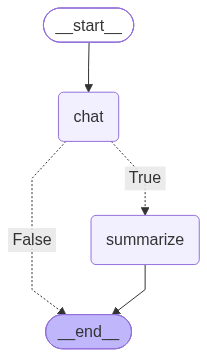

In [30]:
graph

In [31]:
config = {"configurable": {"thread_id": "t1"}}

def run_turn(text: str):
    out = graph.invoke({"messages": [HumanMessage(content=text)], "summary": ""}, config=config)
    return out

In [32]:
# gives the current version of the state
def show_state():
    snap = graph.get_state(config)
    vals = snap.values
    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")
    for m in vals.get("messages", []):
        print("-", type(m).__name__, ":", m.content[:80])

In [33]:
run_turn('Quantum Physics')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2bb0419-8548-4df6-9a1d-f61830b5b58b')]

--- STATE ---
summary: 
num_messages: 2
messages:
- HumanMessage : Quantum Physics
- AIMessage : Quantum physics, also known as quantum mechanics, is a fundamental theory in phy


In [34]:
run_turn('How is Albert Einstien related?')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2bb0419-8548-4df6-9a1d-f61830b5b58b'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy on the smallest scales, at the level of atoms and subatomic particles. It is a branch of physics that deals with the behavior of matter and energy at the quantum level, which is the level of individual particles such as electrons and photons.\n\nQuantum physics is characterized by several key principles, including superposition, entanglement, and the uncertainty principle. Superposition refers to the idea that particles can exist in multiple states at the same time, while entanglement describes the phenomenon where particles become correlated in such a way that the state of one particle is dependent on the state of another, even if they are separated by large distances. The uncertainty principle states that i

In [35]:
run_turn('What are some of Einstien"s fampus work ? Explain in short')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2bb0419-8548-4df6-9a1d-f61830b5b58b'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy on the smallest scales, at the level of atoms and subatomic particles. It is a branch of physics that deals with the behavior of matter and energy at the quantum level, which is the level of individual particles such as electrons and photons.\n\nQuantum physics is characterized by several key principles, including superposition, entanglement, and the uncertainty principle. Superposition refers to the idea that particles can exist in multiple states at the same time, while entanglement describes the phenomenon where particles become correlated in such a way that the state of one particle is dependent on the state of another, even if they are separated by large distances. The uncertainty principle states that i

In [36]:
run_turn('Explain special theory of relativity, explain in short')
show_state()

[HumanMessage(content='Quantum Physics', additional_kwargs={}, response_metadata={}, id='d2bb0419-8548-4df6-9a1d-f61830b5b58b'), AIMessage(content='Quantum physics, also known as quantum mechanics, is a fundamental theory in physics that describes the behavior of matter and energy on the smallest scales, at the level of atoms and subatomic particles. It is a branch of physics that deals with the behavior of matter and energy at the quantum level, which is the level of individual particles such as electrons and photons.\n\nQuantum physics is characterized by several key principles, including superposition, entanglement, and the uncertainty principle. Superposition refers to the idea that particles can exist in multiple states at the same time, while entanglement describes the phenomenon where particles become correlated in such a way that the state of one particle is dependent on the state of another, even if they are separated by large distances. The uncertainty principle states that i